In [1]:
# ============================================
# Imports
# ============================================
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from xgboost import XGBClassifier

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [2]:
# ============================================
# Load and preprocess Iris
# ============================================
df = pd.read_csv("Iris.csv")

# adjust 'species' to whatever your target column is named (e.g. 'class', 'Species')
target_col = 'species'

X = df.drop(columns=["Species", "Id"])
y = df["Species"]

# encode labels (needed for XGBoost, harmless for others)
le = LabelEncoder()
y_enc = le.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
x_test_scaled  = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)

In [3]:
# ============================================
# Model configs: name -> (estimator, param_grid)
# ============================================
def get_model_configs():
    return {
        'SVM': (SVC(probability=True, random_state=42),
                {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}),

        'Naive Bayes': (GaussianNB(),
                {'var_smoothing': [1e-9, 1e-8, 1e-7]}),

        'KNN': (KNeighborsClassifier(),
                {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}),

        'Logistic Regression': (LogisticRegression(max_iter=5000, random_state=42),
                {'C': [0.01, 0.1, 1, 10]}),

        'Decision Tree': (DecisionTreeClassifier(random_state=42),
                {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy']}),

        'Random Forest': (RandomForestClassifier(random_state=42),
                {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}),

        'AdaBoost': (AdaBoostClassifier(random_state=42),
                {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]}),

        'Gradient Boosting': (GradientBoostingClassifier(random_state=42),
                {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}),

        'XGBoost': (XGBClassifier(random_state=42, eval_metric='mlogloss'),
                {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}),

        'Stacking': (StackingClassifier(
                        estimators=[('svm', SVC(probability=True, random_state=42)),
                                    ('nb', GaussianNB()),
                                    ('dt', DecisionTreeClassifier(random_state=42))],
                        final_estimator=LogisticRegression(max_iter=1000),
                        cv=cv_strategy),
                {})  # baseline only, no grid search
    }

In [4]:
# ============================================
# Core function: train + tune + CV all models
# on WHATEVER feature set you pass it (raw or PCA)
# ============================================
def run_all_models(x_train, y_train, x_test, y_test, cv=cv_strategy, scoring='accuracy'):
    model_configs = get_model_configs()
    results = []

    for name, (estimator, param_grid) in model_configs.items():
        print(f"Running {name}...")
        start = time.time()

        if param_grid:
            search = GridSearchCV(estimator, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
            search.fit(x_train, y_train)
            best_model = search.best_estimator_
            best_params = search.best_params_
        else:
            best_model = estimator.fit(x_train, y_train)
            best_params = {}

        elapsed = time.time() - start

        fold_acc = cross_val_score(best_model, x_train, y_train, cv=cv, scoring='accuracy')
        fold_f1  = cross_val_score(best_model, x_train, y_train, cv=cv, scoring='f1_weighted')

        y_pred = best_model.predict(x_test)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='weighted')

        row = {
            'Model': name,
            'Best Params': best_params,
            'Fold 1': fold_acc[0], 'Fold 2': fold_acc[1], 'Fold 3': fold_acc[2],
            'Fold 4': fold_acc[3], 'Fold 5': fold_acc[4],
            'Avg CV Accuracy': fold_acc.mean(),
            'Std CV Accuracy': fold_acc.std(),
            'Avg CV F1': fold_f1.mean(),
            'Test Accuracy': test_acc,
            'Test F1': test_f1,
            'Train Time (s)': elapsed
        }
        results.append(row)

    return pd.DataFrame(results)

In [5]:
# ============================================
# BLOCK 1 — Without PCA
# ============================================
results_no_pca = run_all_models(x_train_scaled, y_train, x_test_scaled, y_test)
results_no_pca

Running SVM...


/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probab

Running Naive Bayes...
Running KNN...
Running Logistic Regression...
Running Decision Tree...
Running Random Forest...
Running AdaBoost...
Running Gradient Boosting...
Running XGBoost...
Running Stacking...


/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probab

,Model,Best Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg CV Accuracy,Std CV Accuracy,Avg CV F1,Test Accuracy,Test F1,Train Time (s)
0,SVM,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.958333,1.000000,0.958333,0.958333,1.000000,0.975000,0.020412,0.974902,0.933333,0.933333,2.217804
1,Naive Bayes,{'var_smoothing': 1e-09},0.958333,0.958333,0.958333,0.958333,0.916667,0.950000,0.016667,0.949605,0.966667,0.966583,0.026926
2,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.958333,1.000000,0.958333,0.958333,0.958333,0.966667,0.016667,0.966536,0.933333,0.932660,0.066212
3,Logistic Regression,{'C': 10},1.000000,1.000000,0.958333,0.958333,0.916667,0.966667,0.031180,0.966337,1.000000,1.000000,0.027245
4,Decision Tree,"{'criterion': 'gini', 'max_depth': 3}",1.000000,1.000000,0.958333,0.958333,0.916667,0.966667,0.031180,0.966337,0.966667,0.966583,0.048247
5,Random Forest,"{'max_depth': 5, 'n_estimators': 100}",0.958333,1.000000,0.958333,0.916667,0.916667,0.950000,0.031180,0.949406,0.900000,0.899749,0.546225
6,AdaBoost,"{'learning_rate': 0.5, 'n_estimators': 50}",0.958333,0.916667,0.958333,0.916667,0.916667,0.933333,0.020412,0.932474,0.900000,0.899749,0.199687
7,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.958333,0.958333,1.000000,0.916667,0.916667,0.950000,0.031180,0.949406,0.933333,0.933333,0.852328
8,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.958333,1.000000,0.958333,0.916667,0.916667,0.950000,0.031180,0.949637,0.933333,0.933333,0.203222
9,Stacking,{},0.958333,1.000000,0.958333,0.958333,0.916667,0.958333,0.026352,0.957971,0.966667,0.966583,0.032727


In [6]:
# ============================================
# BLOCK 2 — With PCA
# ============================================
pca = PCA(n_components=0.95, random_state=42)   # keep 95% variance
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca  = pca.transform(x_test_scaled)

print(f"Components kept: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

results_with_pca = run_all_models(x_train_pca, y_train, x_test_pca, y_test)
results_with_pca

Components kept: 2
Explained variance: 95.73%
Running SVM...
Running Naive Bayes...
Running KNN...
Running Logistic Regression...


/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probab

Running Decision Tree...
Running Random Forest...
Running AdaBoost...
Running Gradient Boosting...
Running XGBoost...
Running Stacking...


/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probab

,Model,Best Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg CV Accuracy,Std CV Accuracy,Avg CV F1,Test Accuracy,Test F1,Train Time (s)
0,SVM,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.916667,0.916667,0.875000,0.958333,0.958333,0.925000,0.031180,0.924837,0.900000,0.899749,0.054566
1,Naive Bayes,{'var_smoothing': 1e-09},0.958333,0.916667,0.833333,0.833333,0.916667,0.891667,0.050000,0.890840,0.866667,0.865320,0.013252
2,KNN,"{'n_neighbors': 5, 'weights': 'uniform'}",0.875000,0.916667,0.875000,0.958333,0.916667,0.908333,0.031180,0.907840,0.900000,0.899749,0.024870
3,Logistic Regression,{'C': 10},0.916667,0.875000,0.875000,1.000000,0.958333,0.925000,0.048591,0.924507,0.900000,0.899749,0.025476
4,Decision Tree,"{'criterion': 'gini', 'max_depth': 3}",0.958333,0.875000,0.875000,0.875000,0.916667,0.900000,0.033333,0.898596,0.900000,0.899749,0.036396
5,Random Forest,"{'max_depth': 5, 'n_estimators': 200}",0.916667,0.875000,0.875000,0.916667,0.916667,0.900000,0.020412,0.899275,0.900000,0.899749,0.546671
6,AdaBoost,"{'learning_rate': 0.5, 'n_estimators': 100}",0.916667,0.833333,0.916667,0.875000,0.916667,0.891667,0.033333,0.891040,0.866667,0.865320,0.231426
7,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.916667,0.958333,0.875000,0.833333,0.916667,0.900000,0.042492,0.899605,0.900000,0.899749,0.842273
8,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.916667,0.916667,0.916667,0.833333,0.916667,0.900000,0.033333,0.899412,0.866667,0.864829,0.204667
9,Stacking,{},0.916667,0.875000,0.875000,0.875000,0.916667,0.891667,0.020412,0.891108,0.900000,0.899749,0.022578


In [7]:
# ============================================
# Combine into one comparison table (matches Table 5 in the report)
# ============================================
comparison = results_no_pca[['Model', 'Avg CV Accuracy', 'Avg CV F1']].rename(
    columns={'Avg CV Accuracy': 'Avg Accuracy (No-PCA)', 'Avg CV F1': 'Avg F1 (No-PCA)'}
).merge(
    results_with_pca[['Model', 'Avg CV Accuracy', 'Avg CV F1']].rename(
        columns={'Avg CV Accuracy': 'Avg Accuracy (With-PCA)', 'Avg CV F1': 'Avg F1 (With-PCA)'}
    ),
    on='Model'
)
comparison

,Model,Avg Accuracy (No-PCA),Avg F1 (No-PCA),Avg Accuracy (With-PCA),Avg F1 (With-PCA)
0,SVM,0.975000,0.974902,0.925000,0.924837
1,Naive Bayes,0.950000,0.949605,0.891667,0.890840
2,KNN,0.966667,0.966536,0.908333,0.907840
3,Logistic Regression,0.966667,0.966337,0.925000,0.924507
4,Decision Tree,0.966667,0.966337,0.900000,0.898596
5,Random Forest,0.950000,0.949406,0.900000,0.899275
6,AdaBoost,0.933333,0.932474,0.891667,0.891040
7,Gradient Boosting,0.950000,0.949406,0.900000,0.899605
8,XGBoost,0.950000,0.949637,0.900000,0.899412
9,Stacking,0.958333,0.957971,0.891667,0.891108


Explained Variance by Component:


,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.724549,0.724549
1,PC2,0.232731,0.957280



PCA Loadings (feature contribution to each component):


,PC1,PC2
SepalLengthCm,0.528377,0.341708
SepalWidthCm,-0.245403,0.937341
PetalLengthCm,0.582854,0.022497
PetalWidthCm,0.566459,0.064193



Most influential original feature per component:
  PC1: PetalLengthCm (loading = 0.583)
  PC2: SepalWidthCm (loading = 0.937)


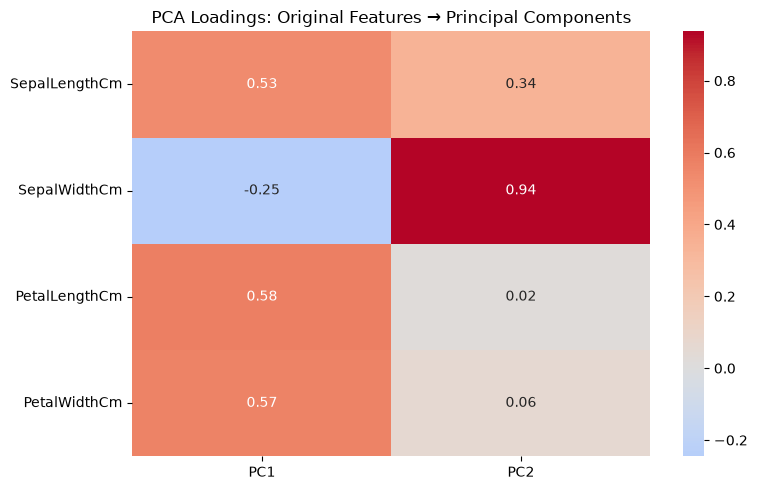

In [8]:
# ============================================
# What changed: original features vs PCA components
# ============================================

# 1. Explained variance per component2
explained_var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(pca.n_components_)],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})
print("Explained Variance by Component:")
display(explained_var_df)

# 2. Loadings: how much each original feature contributes to each PC
# pca.components_ shape = (n_components, n_original_features)
loadings_df = pd.DataFrame(
    pca.components_.T,   # transpose so rows = original features, cols = PCs
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print("\nPCA Loadings (feature contribution to each component):")
display(loadings_df)

# 3. Which original feature dominates each component
dominant_features = loadings_df.abs().idxmax(axis=0)
print("\nMost influential original feature per component:")
for pc, feat in dominant_features.items():
    print(f"  {pc}: {feat} (loading = {loadings_df.loc[feat, pc]:.3f})")

# 4. Heatmap of loadings (visual "before vs after" feature mapping)
plt.figure(figsize=(8, 5))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("PCA Loadings: Original Features → Principal Components")
plt.tight_layout()
import os
os.makedirs('./images', exist_ok=True)
plt.savefig('./images/exp7_plot_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [9]:
from scipy.stats import f_oneway

# Collect fold accuracies per model (from your No-PCA run)
fold_cols = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

model_fold_scores = {
    row['Model']: row[fold_cols].values.astype(float)
    for _, row in results_no_pca.iterrows()
}

# One-way ANOVA across all models
f_stat, p_value = f_oneway(*model_fold_scores.values())

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference exists between at least one pair of models.")
else:
    print("No statistically significant difference between models.")

F-statistic: 0.8711
p-value: 0.5582
No statistically significant difference between models.


In [10]:
from scipy.stats import ttest_rel

fold_cols = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

# Extract KNN's fold scores from each results table
knn_no_pca = results_no_pca.loc[results_no_pca['Model'] == 'KNN', fold_cols].values.flatten().astype(float)
knn_with_pca = results_with_pca.loc[results_with_pca['Model'] == 'KNN', fold_cols].values.flatten().astype(float)

print("KNN No-PCA folds:  ", knn_no_pca)
print("KNN With-PCA folds:", knn_with_pca)

t_stat, p_value = ttest_rel(knn_no_pca, knn_with_pca)

print(f"\nPaired t-test: t = {t_stat:.4f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant difference between KNN's No-PCA and With-PCA performance.")
else:
    print("No statistically significant difference — PCA did not meaningfully change KNN's performance.")


diffs = knn_no_pca - knn_with_pca
print("Differences:", diffs)
print("Std of differences:", diffs.std())

if diffs.std() == 0:
    print("KNN scores are identical across all folds before/after PCA.")
    print("t-test undefined (zero variance in differences) — this itself indicates PCA had no effect on KNN.")
else:
    t_stat, p_value = ttest_rel(knn_no_pca, knn_with_pca)
    print(f"Paired t-test: t = {t_stat:.4f}, p = {p_value:.4f}")

KNN No-PCA folds:   [0.95833333 1.         0.95833333 0.95833333 0.95833333]
KNN With-PCA folds: [0.875      0.91666667 0.875      0.95833333 0.91666667]

Paired t-test: t = 3.5000, p = 0.0249
Statistically significant difference between KNN's No-PCA and With-PCA performance.
Differences: [0.08333333 0.08333333 0.08333333 0.         0.04166667]
Std of differences: 0.03333333333333334
Paired t-test: t = 3.5000, p = 0.0249
